# Data Preparation for Probe Training

## Imports

In [1]:
import os
import torch
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

## Loading the Activation Datasets

### Loading and Prepping the Training Set

In [2]:
suf_path = r"C:\Users\SATI0004\Documents\LLM_mech_interp\simple-evals\outputs\BioMistral\biomistral_setA_sufficient_hidden.pt"
ins_path = r"C:\Users\SATI0004\Documents\LLM_mech_interp\simple-evals\outputs\BioMistral\biomistral_setA_insufficient_hidden.pt"

# Loading the hidden state activations
suf_obj = torch.load(suf_path, map_location="cpu")
ins_obj = torch.load(ins_path, map_location="cpu")

# these are the hidden state vectors
X_suf = suf_obj["hidden_states"]
X_ins = ins_obj["hidden_states"]

# the metadata contains more info like the prompt_id and label
meta_suf = suf_obj["metadata"]
meta_ins = ins_obj["metadata"]

print("Sufficient shape:", X_suf.shape)
print("Insufficient shape:", X_ins.shape)

Sufficient shape: torch.Size([442, 32, 4096])
Insufficient shape: torch.Size([361, 32, 4096])


In [3]:
X = torch.cat([X_suf, X_ins], dim=0)
metadata = meta_suf + meta_ins

metadata_df = pd.DataFrame(metadata)
y = metadata_df["binary_label"].to_numpy()

print("Combined hidden states shape:", X.shape)
print(metadata_df["binary_label"].value_counts())

Combined hidden states shape: torch.Size([803, 32, 4096])
binary_label
0    442
1    361
Name: count, dtype: int64


### Loading and Prepping the Test Set

In [4]:
# Loading the Test set - Hard Set as well
suff_hard_obj = torch.load(r"C:\Users\SATI0004\Documents\LLM_mech_interp\simple-evals\outputs\BioMistral\HARD_BioMistral_setA_sufficient_hidden.pt", map_location="cpu")
insuff_hard_obj = torch.load(r"C:\Users\SATI0004\Documents\LLM_mech_interp\simple-evals\outputs\BioMistral\HARD_BioMistral_setA_insufficient_hidden.pt", map_location="cpu")

X_suff_hard = suff_hard_obj["hidden_states"]
X_insuff_hard = insuff_hard_obj["hidden_states"]

X_suff_hard_metadata = suff_hard_obj["metadata"]
X_insuff_hard_metadata = insuff_hard_obj["metadata"]

print("X_test (Hard) Sufficient shape:", X_suff_hard.shape)
print("X_test (Hard) Insufficient shape:", X_insuff_hard.shape)

X_test (Hard) Sufficient shape: torch.Size([54, 32, 4096])
X_test (Hard) Insufficient shape: torch.Size([134, 32, 4096])


In [5]:
X_test = torch.cat([X_suff_hard, X_insuff_hard], dim=0)
X_test_metadata = pd.DataFrame(X_suff_hard_metadata + X_insuff_hard_metadata)
y_test = X_test_metadata['binary_label'].to_numpy()

print("Combined hidden states shape:", X_test.shape)
print(X_test_metadata["binary_label"].value_counts())

Combined hidden states shape: torch.Size([188, 32, 4096])
binary_label
1    134
0     54
Name: count, dtype: int64


### Removing the Hard Examples from the Train and Validation Sets

In [12]:
# -----------------------------
# Remove Hard examples from OSS
# -----------------------------

# Hard prompt IDs
hard_prompt_ids = set(X_test_metadata["prompt_id"].tolist())

print("Number of Hard prompt IDs:", len(hard_prompt_ids))

# Build OSS metadata dataframe again
metadata_df = pd.DataFrame(metadata)

# Keep only OSS examples whose prompt_id is NOT in Hard
keep_mask = ~metadata_df["prompt_id"].isin(hard_prompt_ids)

X_oss_clean = X[keep_mask.to_numpy()]
metadata_oss_clean = [metadata[i] for i, keep in enumerate(keep_mask) if keep]
metadata_oss_clean_df = pd.DataFrame(metadata_oss_clean)
y_oss_clean = metadata_oss_clean_df["binary_label"].to_numpy()

print("Original OSS size :", X.shape[0])
print("Filtered OSS size :", X_oss_clean.shape[0])
print("Removed overlap   :", X.shape[0] - X_oss_clean.shape[0])
print("\nFiltered OSS label counts:")
print(metadata_oss_clean_df["binary_label"].value_counts())

Number of Hard prompt IDs: 188
Original OSS size : 803
Filtered OSS size : 615
Removed overlap   : 188

Filtered OSS label counts:
binary_label
0    388
1    227
Name: count, dtype: int64


In [13]:
# -----------------------------
# Train/Val split on clean OSS
# -----------------------------

indices_clean = np.arange(len(y_oss_clean))

train_idx, val_idx = train_test_split(
    indices_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_oss_clean
)

X_train = X_oss_clean[train_idx]
X_val = X_oss_clean[val_idx]

y_train = y_oss_clean[train_idx]
y_val = y_oss_clean[val_idx]

meta_train = [metadata_oss_clean[i] for i in train_idx]
meta_val = [metadata_oss_clean[i] for i in val_idx]

print("Clean Train:", X_train.shape, len(y_train))
print("Clean Val  :", X_val.shape, len(y_val))
print("Hard Test  :", X_test.shape, len(y_test))

Clean Train: torch.Size([492, 32, 4096]) 492
Clean Val  : torch.Size([123, 32, 4096]) 123
Hard Test  : torch.Size([188, 32, 4096]) 188


In [15]:
# -----------------------------
# Sanity check: no overlap
# -----------------------------

train_ids = set([m["prompt_id"] for m in meta_train])
val_ids = set([m["prompt_id"] for m in meta_val])
hard_ids = set(X_test_metadata["prompt_id"].tolist())

print("Train-Val overlap  :", len(train_ids.intersection(val_ids)))
print("Train-Hard overlap :", len(train_ids.intersection(hard_ids)))
print("Val-Hard overlap   :", len(val_ids.intersection(hard_ids)))

Train-Val overlap  : 0
Train-Hard overlap : 0
Val-Hard overlap   : 0


## Training a Probe Layer by Layer

In [16]:
results = []

num_layers = X_train.shape[1]

for layer in range(num_layers):
    Xtr = X_train[:, layer, :].float().numpy()
    Xva = X_val[:, layer, :].float().numpy()

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    )
    clf.fit(Xtr, y_train)

    y_pred = clf.predict(Xva)
    y_prob = clf.predict_proba(Xva)[:, 1]

    results.append({
        "layer": layer,
        "accuracy": accuracy_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
        "f1": f1_score(y_val, y_pred),
        "auroc": roc_auc_score(y_val, y_prob)
    })

In [17]:
print(layer, clf.n_iter_)

31 [124]


### Viewing the Best Layer

In [18]:
results_df = pd.DataFrame(results)
results_df.sort_values("auroc", ascending=False)

,layer,accuracy,balanced_accuracy,f1,auroc
15,15,0.764228,0.724786,0.641975,0.815100
20,20,0.756098,0.708974,0.615385,0.805698
16,16,0.756098,0.713675,0.625000,0.803419
13,13,0.747967,0.721368,0.643678,0.801140
21,21,0.764228,0.720085,0.632911,0.796866
19,19,0.731707,0.680342,0.571429,0.788034
14,14,0.731707,0.699145,0.611765,0.787179
17,17,0.747967,0.697863,0.597403,0.783761
11,11,0.723577,0.692735,0.604651,0.780057
12,12,0.739837,0.705556,0.619048,0.779487


### Plot Performance Across Layers

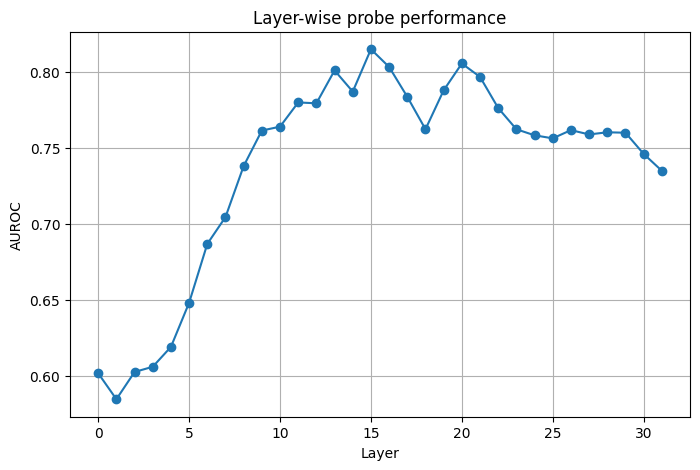

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results_df["layer"], results_df["auroc"], marker="o")
plt.xlabel("Layer")
plt.ylabel("AUROC")
plt.title("Layer-wise probe performance")
plt.grid(True)
plt.show()

In [20]:
print("Best 5 layers by AUROC:")
for layer in results_df.sort_values("auroc", ascending=False)["layer"].head(5):
    Xtr = X_train[:, layer, :].float().numpy()
    Xva = X_val[:, layer, :].float().numpy()

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    )
    clf.fit(Xtr, y_train)
    print(f"Layer {layer}: n_iter = {clf.n_iter_}")

Best 5 layers by AUROC:
Layer 15: n_iter = [38]
Layer 20: n_iter = [74]
Layer 16: n_iter = [54]
Layer 13: n_iter = [38]
Layer 21: n_iter = [81]


In [21]:
print("X_test shape:", X_test.shape)
print("len(meta_test):", len(X_test_metadata))
print("len(y_test):", len(y_test))
print(X_test_metadata["binary_label"].value_counts())

X_test shape: torch.Size([188, 32, 4096])
len(meta_test): 188
len(y_test): 188
binary_label
1    134
0     54
Name: count, dtype: int64


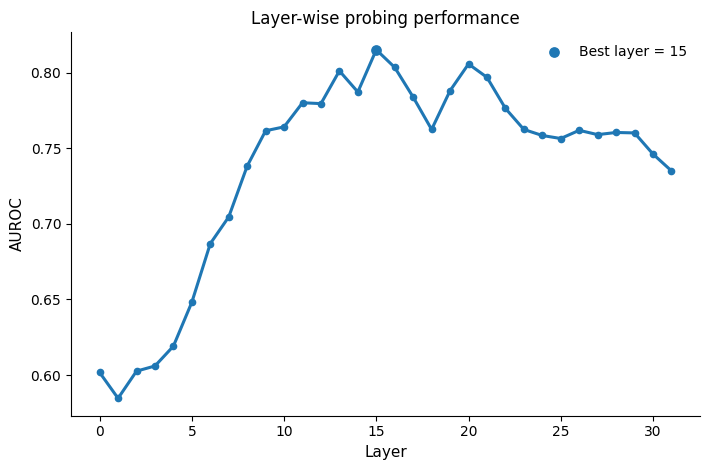

In [22]:
results_df = results_df.sort_values("layer").reset_index(drop=True)

best_row = results_df.sort_values("auroc", ascending=False).iloc[0]
best_layer = int(best_row["layer"])
best_auroc = float(best_row["auroc"])

plt.figure(figsize=(7.2, 4.8))
plt.plot(
    results_df["layer"],
    results_df["auroc"],
    marker="o",
    linewidth=2.2,
    markersize=4.5
)

plt.scatter(
    [best_layer],
    [best_auroc],
    s=45,
    zorder=3,
    label=f"Best layer = {best_layer}"
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.xlabel("Layer", fontsize=11)
plt.ylabel("AUROC", fontsize=11)
plt.title("Layer-wise probing performance", fontsize=12)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

BioMistral is a decoder-only transformer based on the Mistral architecture. In such models, "before generation" does not correspond to a specific intermediate layer, but to the state after the full prompt has been processed through all transformer layers and immediately before the first response token is produced. We therefore extract the hidden state of the final prompt token at every layer, allowing us to examine how evidence-sufficiency information evolves across depth. Therefore, at this stage - since its the last token in the prompt, this encapsulates the final understanding of the prompt in the model. 

 Our results show that evidence sufficiency is most linearly decodable in the middle layers, peaking around layer 12. This should not be interpreted as generation beginning at layer 15 or as evidence-insufficiency awareness being localized to a single layer. Rather, it indicates that the relevant signal becomes especially accessible to a linear probe at that depth, while likely remaining distributed across multiple layers of the network.

 NOTE: The above 2 graphs are the same - one with background grid and one without thats it!

## Training the Final Probe at the Best OSS Layer

In [23]:
best_layer = int(results_df.sort_values("auroc", ascending=False).iloc[0]["layer"])
print("Best layer:", best_layer)

Xtr_best = X_train[:, best_layer, :].float().numpy()
Xva_best = X_val[:, best_layer, :].float().numpy()

best_clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)
best_clf.fit(Xtr_best, y_train)

y_val_pred = best_clf.predict(Xva_best)
y_val_prob = best_clf.predict_proba(Xva_best)[:, 1]

print("Validation metrics at best layer")
print("Accuracy         :", accuracy_score(y_val, y_val_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_pred))
print("F1               :", f1_score(y_val, y_val_pred))
print("AUROC            :", roc_auc_score(y_val, y_val_prob))
print("Iterations used  :", best_clf.n_iter_)

Best layer: 15
Validation metrics at best layer
Accuracy         : 0.7642276422764228
Balanced Accuracy: 0.7247863247863248
F1               : 0.6419753086419753
AUROC            : 0.8150997150997151
Iterations used  : [38]


### Getting the Concept Activation Vector

In [24]:
cav = best_clf.coef_[0]
bias = best_clf.intercept_[0]
cav_unit = cav / np.linalg.norm(cav)

print("CAV shape:", cav.shape)
print("Bias:", bias)
print("First 10 CAV values:", cav[:10])

CAV shape: (4096,)
Bias: -1.6724027273606175
First 10 CAV values: [-0.20328724  0.0479023  -0.02536351 -0.00557805  0.00870431  0.12947778
 -0.08986862  0.09994271  0.05082454  0.23677624]


best_clf.coef_[0] is the normal vector to the decision hyperplane separating sufficient and insufficient examples at that layer.

This Concept Activation Vector (CAV) encodes for evidence insufficiency, the label map is as follows:

- 0 - Evidence is Sufficient
- 1 - Evidence is Insufficient



**Geometric Intuition**

For an activation vector h, the probe computes:

z = w^\top h + b

and then logistic regression turns it into a probability:

p(y=1 \mid h) = \sigma(z)

So:
	•	if z is large and positive, the probe predicts insufficient
	•	if z is negative, the probe predicts sufficient

### Plot Projection of the Validation Scores

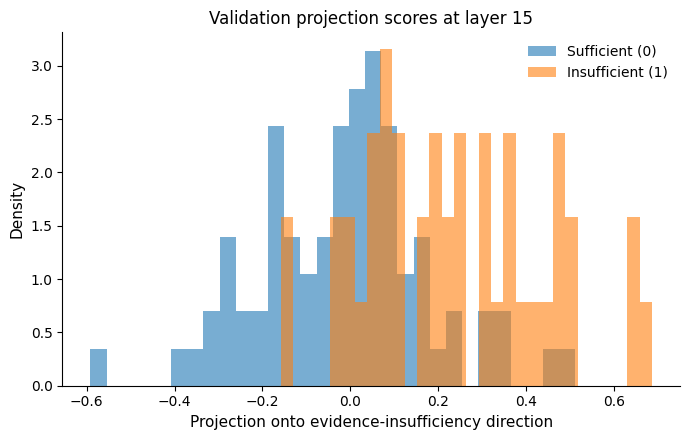

In [25]:
proj_scores_val = Xva_best @ cav_unit

val_proj_df = pd.DataFrame({
    "projection_score": proj_scores_val,
    "binary_label": y_val
})

proj_suf = val_proj_df[val_proj_df["binary_label"] == 0]["projection_score"]
proj_ins = val_proj_df[val_proj_df["binary_label"] == 1]["projection_score"]

plt.figure(figsize=(7.0, 4.5))
plt.hist(proj_suf, bins=30, alpha=0.6, density=True, label="Sufficient (0)")
plt.hist(proj_ins, bins=30, alpha=0.6, density=True, label="Insufficient (1)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.xlabel("Projection onto evidence-insufficiency direction", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title(f"Validation projection scores at layer {best_layer}", fontsize=12)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

This histogram is plotting, for layer 15, where it shows:

	•	the distribution of projection scores for sufficient prompts
	•	the distribution of projection scores for insufficient prompts

where the projection score is:

**score = h^T v**

with:

	•	h = hidden state at layer 15
	•	v = the learned evidence-insufficiency direction (the CAV-like vector)

So each point on the x-axis tells us:  *how strongly that prompt’s internal representation aligns with the evidence-insufficiency direction.*

-------------

This matters for our hypothesis:  **Does BioMistral internally represent evidence sufficiency / insufficiency before generation?**

Ans: Yes, to a meaningful extent. Because if the model did not internally encode this distinction at all, then the two distributions would heavily overlap with no clear shift. Instead, you see a noticeable distributional separation:

	•	sufficient prompts cluster at lower scores
	•	insufficient prompts cluster at higher scores

So the internal activations at layer 15 are carrying information that distinguishes the two conditions.

-------------

However, the two distributions still overlap quite a bit, which means:

	•	the signal is real but not perfect
	•	evidence insufficiency is not encoded as a perfectly clean binary feature
	•	some sufficient prompts look somewhat insufficiency-like internally
	•	some insufficient prompts look somewhat sufficiency-like internally


Therefore, the model’s layer-15 representation contains a meaningful but partially entangled signal predictive of evidence insufficiency.

-------------

If layer 15 is now your best layer, that suggests the signal is strongest in the middle-to-late middle part of the network.

That fits a nice mechanistic story:

	•	early layers: more local / lexical / shallow information
	•	middle layers: integration of prompt context into a task-relevant representation
	•	later layers: closer to response planning, where the signal may remain but get mixed with output-oriented features

So layer 15 being best suggests:

BioMistral seems to form its clearest internal evidence-sufficiency representation after several rounds of contextual integration, rather than encoding it purely at the surface or only at the final output stage.

It does not mean:

	•	evidence insufficiency is only present at layer 15
	•	generation starts at layer 15

Instead, it means:

**among the layer-wise representations of the last prompt token, the one at layer 15 gives the cleanest linear readout of evidence insufficiency.**

So layer 15 is the best readout layer, NOT the unique “awareness layer.”

-------------

In the context of this paper, this supports the claim that:

	•	BioMistral does not treat sufficient and insufficient prompts identically internally
	•	there is a direction in hidden-state space that corresponds meaningfully to evidence insufficiency
	•	that direction is strong enough that a simple linear classifier can partially separate the two classes

**This argues against the idea that hallucination under insufficient evidence is purely due to complete absence of an internal signal.** -- NOT a useful hypothesis :(

Better:

**Much of the literature evaluates hallucination at the output level, which leaves unresolved whether failures under insufficient evidence arise from absence of an internal insufficiency signal or from failure to use such a signal during generation.**

Instead, it supports the possibility that:

	•	the model may already internally represent insufficiency,
	•	but later behavior may or may not use that signal appropriately

That is exactly the bridge to your later “representation vs utilization failure” argument.


Projection of validation hidden states onto the probe-derived evidence-insufficiency direction at layer 15 reveals a clear distributional shift between sufficient and insufficient prompts. Insufficient examples tend to have larger projection scores, indicating stronger alignment with the learned insufficiency direction, whereas sufficient examples are concentrated at lower scores. Although the distributions overlap, their separation supports the conclusion that BioMistral’s layer-15 internal representations contain a meaningful linear signal related to evidence sufficiency.

## Testing the Model Trained on the Best Layer on the Test Set

### Extracting the Best Layer Activations

In [26]:
Xte_best = X_test[:, best_layer, :].float().numpy()

y_test_pred = best_clf.predict(Xte_best)
y_test_prob = best_clf.predict_proba(Xte_best)[:, 1]

print("Hard-set evaluation at best OSS layer")
print("Accuracy         :", accuracy_score(y_test, y_test_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print("F1               :", f1_score(y_test, y_test_pred))
print("AUROC            :", roc_auc_score(y_test, y_test_prob))

Hard-set evaluation at best OSS layer
Accuracy         : 0.5797872340425532
Balanced Accuracy: 0.6775843007186291
F1               : 0.6030150753768844
AUROC            : 0.7483416252072969


### Plotting the Projection Scores

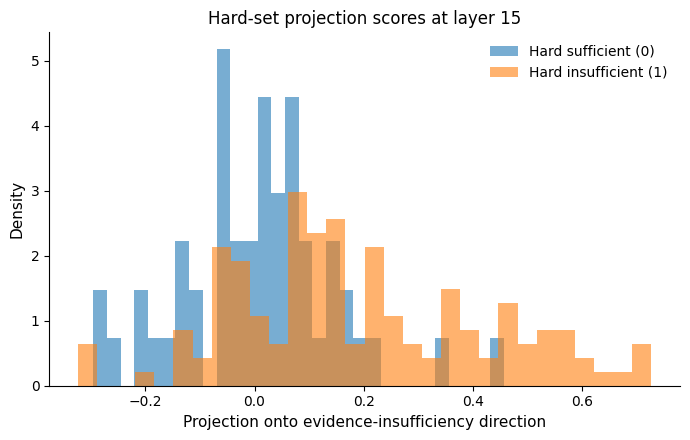

In [27]:
# Projection scores on Hard
test_proj_scores = Xte_best @ cav_unit

test_proj_df = pd.DataFrame({
    "projection_score": test_proj_scores,
    "binary_label": y_test
})

proj_suf_test = test_proj_df[test_proj_df["binary_label"] == 0]["projection_score"]
proj_ins_test = test_proj_df[test_proj_df["binary_label"] == 1]["projection_score"]

plt.figure(figsize=(7.0, 4.5))
plt.hist(proj_suf_test, bins=30, alpha=0.6, density=True, label="Hard sufficient (0)")
plt.hist(proj_ins_test, bins=30, alpha=0.6, density=True, label="Hard insufficient (1)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.xlabel("Projection onto evidence-insufficiency direction", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title(f"Hard-set projection scores at layer {best_layer}", fontsize=12)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

When evaluated on a disjoint held-out Hard subset, the best layer selected on the OSS validation split retained meaningful predictive performance (AUROC = 0.748, balanced accuracy = 0.678), indicating that the learned evidence-sufficiency signal generalizes beyond the development data. Projection-score distributions on the Hard set showed that insufficient prompts remained shifted toward higher alignment with the probe-derived evidence-insufficiency direction, although with greater overlap than on validation. Together, these findings suggest that BioMistral’s hidden states contain a real but imperfectly separable internal signal related to evidence sufficiency, rather than being entirely blind to insufficient patient-specific evidence.

### Saving the artifacts

In [ ]:
save_dir = r"C:\Users\SATI0004\Documents\LLM_mech_interp\simple-evals\outputs\BioMistral\probe_results"
os.makedirs(save_dir, exist_ok=True)

# save sklearn probe
joblib.dump(best_clf, os.path.join(save_dir, "best_layer_probe.joblib"))

# save CAV + metadata
torch.save(
    {
        "best_layer": best_layer,
        "cav": cav,
        "cav_unit": cav_unit,
        "bias": bias,
        "val_metrics": {
            "accuracy": accuracy_score(y_val, y_val_pred),
            "balanced_accuracy": balanced_accuracy_score(y_val, y_val_pred),
            "f1": f1_score(y_val, y_val_pred),
            "auroc": roc_auc_score(y_val, y_val_prob),
        },
        "test_metrics": {
            "accuracy": accuracy_score(y_test, y_test_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
            "f1": f1_score(y_test, y_test_pred),
            "auroc": roc_auc_score(y_test, y_test_prob),
        }
    },
    os.path.join(save_dir, "best_layer_cav.pt")
)

results_df.to_csv(os.path.join(save_dir, "layerwise_probe_results.csv"), index=False)

print("INFO: Saved probe, CAV, and results.")

INFO: Saved probe, CAV, and results.


### Evaluation on HARD Subset (Test)

In [29]:
X_dev = torch.cat([X_train, X_val], dim=0)
y_dev = np.concatenate([y_train, y_val])

Xdev_best = X_dev[:, best_layer, :].float().numpy()
Xte_best = X_test[:, best_layer, :].float().numpy()

final_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)
final_clf.fit(Xdev_best, y_dev)

y_test_pred_final = final_clf.predict(Xte_best)
y_test_prob_final = final_clf.predict_proba(Xte_best)[:, 1]

print("Final Hard-set evaluation (retrained on all OSS dev data)")
print("Accuracy         :", accuracy_score(y_test, y_test_pred_final))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_test_pred_final))
print("F1               :", f1_score(y_test, y_test_pred_final))
print("AUROC            :", roc_auc_score(y_test, y_test_prob_final))
print("Iterations used  :", final_clf.n_iter_)

Final Hard-set evaluation (retrained on all OSS dev data)
Accuracy         : 0.5797872340425532
Balanced Accuracy: 0.6775843007186291
F1               : 0.6030150753768844
AUROC            : 0.7560807075732449
Iterations used  : [46]


### Strongest Takeaway

These results do not suggest that the model is unable to distinguish sufficient from insufficient evidence altogether. Rather, they indicate that evidence sufficiency is represented in the hidden states to a meaningful but imperfect extent. The signal is sufficiently strong to be decoded above chance on unseen Hard examples, yet not cleanly separable, implying that the model’s internal representation of evidential sufficiency is partial and likely entangled with other prompt features.